# 🛡️ DeepGuard — Kaggle Edition

Configured for the **DF Dataset** (`/kaggle/input/df-dataset/dataset`).

| Feature | Details |
|---|---|
| Dataset | DF Dataset → `dataset/real/` and `dataset/fake/` |
| Storage | `/kaggle/working/` |
| Checkpoint resume | ✅ Auto-resumes if session interrupted |
| Download model | Output tab → Download |

### Before running:
1. Click **+ Add Data** → search **DF dataset** (your dataset) → Add
2. Enable GPU: **Settings → Accelerator → GPU T4 x2**
3. Enable Internet: **Settings → Internet → On**
4. Click **Run All**
5. Download your model from the **Output tab** after training


## 📦 Section 1: Install Dependencies

In [1]:
# Install all required packages
# This may take 2-3 minutes on first run
!pip install -q \
    torch torchvision \
    facenet-pytorch \
    opencv-python-headless \
    scikit-learn \
    matplotlib \
    tqdm \
    Pillow \
    gradio \
    fastapi \
    uvicorn[standard] \
    python-multipart \
    pyngrok \
    aiofiles

print('✅ All dependencies installed!')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 28.3 MB/s eta 0:00:00a 0:00:01
✅ All dependencies installed!


## 📂 Section 2: Setup Output Directories

In [2]:
import os

# Kaggle paths — no Drive mounting needed
# /kaggle/working  → persists for the session and is downloadable
# /kaggle/input    → your uploaded datasets live here
CHECKPOINT_DIR = '/kaggle/working/checkpoints'
OUTPUT_DIR     = '/kaggle/working'

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print(f'Checkpoint dir: {CHECKPOINT_DIR}')
print(f'Output dir:     {OUTPUT_DIR}')
print('Ready!')


Checkpoint dir: /kaggle/working/checkpoints
Output dir:     /kaggle/working
Ready!


## 📁 Section 3: Dataset Setup

### Supported Datasets
| Dataset | Notes |
|---------|-------|
| **FaceForensics++** | Best for face-swap detection. Request access at [github.com/ondyari/FaceForensics](https://github.com/ondyari/FaceForensics) |
| **Celeb-DF** | Celebrity deepfake dataset. Free download. |
| **DFDC (Deepfake Detection Challenge)** | Kaggle competition dataset. |
| **Custom Dataset** | Place images in `dataset/real/` and `dataset/fake/` folders. |

### Required folder structure:
```
dataset/
  real/   ← original (authentic) face images
  fake/   ← deepfake face images
```

For **video datasets**, run Section 3b to extract frames automatically.

In [3]:
import os

# ── Dataset paths ──────────────────────────────────────────────────
BASE_INPUT  = '/kaggle/input/datasets/ch1nn1/df-dataset/dataset'
REAL_VIDEOS = f'{BASE_INPUT}/real'
FAKE_VIDEOS = f'{BASE_INPUT}/fake'

# Extracted frames will be saved here
DATASET_DIR = '/kaggle/working/dataset'
REAL_DIR    = f'{DATASET_DIR}/real'
FAKE_DIR    = f'{DATASET_DIR}/fake'

os.makedirs(REAL_DIR, exist_ok=True)
os.makedirs(FAKE_DIR, exist_ok=True)

CREATE_DEMO_DATASET = False

real_vids = [f for f in os.listdir(REAL_VIDEOS) if f.lower().endswith(('.mp4','.avi','.mov','.mkv'))]
fake_vids = [f for f in os.listdir(FAKE_VIDEOS) if f.lower().endswith(('.mp4','.avi','.mov','.mkv'))]

print(f'Real videos : {len(real_vids)}')
print(f'Fake videos : {len(fake_vids)}')
print(f'Sample real : {real_vids[:3]}')
print(f'Sample fake : {fake_vids[:3]}')


Real videos : 1000
Fake videos : 1000
Sample real : ['123.mp4', '738.mp4', '479.mp4']
Sample fake : ['479_706.mp4', '481_469.mp4', '184_205.mp4']


### Section 3b: Video Frame Extraction (skip if using image dataset)

In [4]:
import cv2
import os
from tqdm import tqdm

def extract_frames(video_dir, output_dir, sample_every_n=10, max_frames_per_video=50):
    """
    Extract frames from all videos in video_dir and save as JPGs to output_dir.
    sample_every_n     : keep 1 out of every N frames
    max_frames_per_video: max frames to extract per video
    """
    os.makedirs(output_dir, exist_ok=True)
    videos = [f for f in os.listdir(video_dir) if f.lower().endswith(('.mp4','.avi','.mov','.mkv'))]
    total_saved = 0

    for video_file in tqdm(videos, desc=f'Extracting {os.path.basename(output_dir)}'):
        cap       = cv2.VideoCapture(os.path.join(video_dir, video_file))
        frame_idx = 0
        saved     = 0
        basename  = os.path.splitext(video_file)[0]

        while cap.isOpened() and saved < max_frames_per_video:
            ret, frame = cap.read()
            if not ret: break
            if frame_idx % sample_every_n == 0:
                out_path = os.path.join(output_dir, f'{basename}_f{frame_idx:05d}.jpg')
                cv2.imwrite(out_path, frame)
                saved      += 1
                total_saved += 1
            frame_idx += 1
        cap.release()

    print(f'Saved {total_saved} frames → {output_dir}')
    return total_saved


# ── Extract frames from real and fake videos ───────────────────────
# sample_every_n=5  → 1 frame every 5 frames (more frames, longer time)
# sample_every_n=10 → 1 frame every 10 frames (fewer frames, faster)
# max_frames_per_video=50 → cap at 50 frames per video

already_extracted = (
    len(os.listdir(REAL_DIR)) > 0 and
    len(os.listdir(FAKE_DIR)) > 0
)

if already_extracted:
    print('Frames already extracted, skipping.')
    print(f'  Real frames: {len(os.listdir(REAL_DIR))}')
    print(f'  Fake frames: {len(os.listdir(FAKE_DIR))}')
else:
    print('Extracting frames from videos...')
    real_n = extract_frames(REAL_VIDEOS, REAL_DIR, sample_every_n=10, max_frames_per_video=50)
    fake_n = extract_frames(FAKE_VIDEOS, FAKE_DIR, sample_every_n=10, max_frames_per_video=50)
    print(f'\nDone! Real: {real_n} frames | Fake: {fake_n} frames | Total: {real_n + fake_n}')

real_count = len(os.listdir(REAL_DIR))
fake_count = len(os.listdir(FAKE_DIR))
print(f'\nDataset ready: Real={real_count} | Fake={fake_count} | Total={real_count + fake_count}')


Extracting frames from videos...


Extracting real: 100%|██████████| 1000/1000 [47:36<00:00,  2.86s/it] 


Saved 43271 frames → /kaggle/working/dataset/real


Extracting fake: 100%|██████████| 1000/1000 [47:29<00:00,  2.85s/it] 

Saved 43271 frames → /kaggle/working/dataset/fake

Done! Real: 43271 frames | Fake: 43271 frames | Total: 86542

Dataset ready: Real=43271 | Fake=43271 | Total=86542


## ⚙️ Section 4: Data Preprocessing & Dataset Class

In [5]:
import os
import torch
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from facenet_pytorch import MTCNN
from tqdm import tqdm

# ── Constants ──────────────────────────────────────────────────────
INPUT_SIZE   = 224
DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

# ── Transform Pipeline ─────────────────────────────────────────────
# Training: includes data augmentation to improve generalization
train_transform = transforms.Compose([
    transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),          # augment: mirror
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.RandomRotation(degrees=10),           # augment: slight rotation
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],      # ImageNet mean
                         [0.229, 0.224, 0.225]),     # ImageNet std
])

# Validation: NO augmentation — clean evaluation
val_transform = transforms.Compose([
    transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])


# ── PyTorch Dataset ────────────────────────────────────────────────
class DeepfakeDataset(Dataset):
    """
    Custom dataset for binary deepfake classification.

    Loads images from two folders:
      - real_dir  → label 0 (Real)
      - fake_dir  → label 1 (Fake)

    Optionally applies MTCNN face detection to crop faces before transform.
    """

    def __init__(self, real_dir, fake_dir, transform=None, use_face_detection=False):
        self.transform          = transform
        self.use_face_detection = use_face_detection
        self.samples            = []  # list of (filepath, label)

        # Load real images → label 0
        for fname in os.listdir(real_dir):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.webp')):
                self.samples.append((os.path.join(real_dir, fname), 0))

        # Load fake images → label 1
        for fname in os.listdir(fake_dir):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.webp')):
                self.samples.append((os.path.join(fake_dir, fname), 1))

        # MTCNN singleton (created once, not per item)
        if use_face_detection:
            self.mtcnn = MTCNN(
                image_size=INPUT_SIZE,
                margin=20,
                keep_all=False,
                device=DEVICE,
                post_process=False,
            )
        else:
            self.mtcnn = None

        print(f'Dataset loaded: {len(self.samples)} images ')
        real_n = sum(1 for _, l in self.samples if l == 0)
        print(f'  Real: {real_n}  |  Fake: {len(self.samples) - real_n}')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        filepath, label = self.samples[idx]

        # Load image
        image = Image.open(filepath).convert('RGB')

        # Optional face detection and crop
        if self.mtcnn is not None:
            try:
                boxes, _ = self.mtcnn.detect(image)
                if boxes is not None and len(boxes) > 0:
                    x1, y1, x2, y2 = [int(max(0, c)) for c in boxes[0]]
                    image = image.crop((x1, y1, x2, y2))
            except Exception:
                pass  # Fall back to full image if detection fails

        # Apply torchvision transforms
        if self.transform:
            image = self.transform(image)

        return image, label


print('✅ Dataset class defined!')

Using device: cuda
✅ Dataset class defined!


## 🧠 Section 5: Model Architecture — ResNet-50

In [6]:
import torch.nn as nn
from torchvision import models


def build_model(model_name: str = 'resnet50', num_classes: int = 2, pretrained: bool = True):
    """
    Build a CNN model with a custom classification head.

    Architecture:
      Input Image
      → CNN Backbone (ResNet-50 or EfficientNet-B4)
      → Global Average Pooling (built into backbone)
      → Dropout(0.4)
      → Fully Connected (2048 → 2)
      → Output: [Real_prob, Fake_prob]

    Args:
        model_name  : 'resnet50' or 'efficientnet_b4'
        num_classes : 2 for binary classification
        pretrained  : use ImageNet weights as starting point

    Returns:
        nn.Module in training mode
    """
    if model_name == 'resnet50':
        weights = models.ResNet50_Weights.DEFAULT if pretrained else None
        model   = models.resnet50(weights=weights)
        in_features = model.fc.in_features   # 2048

        # Replace final layer with binary classification head
        model.fc = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(in_features, num_classes)
        )

    elif model_name == 'efficientnet_b4':
        weights = models.EfficientNet_B4_Weights.DEFAULT if pretrained else None
        model   = models.efficientnet_b4(weights=weights)
        in_features = model.classifier[1].in_features

        model.classifier = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(in_features, num_classes)
        )

    else:
        raise ValueError(f"Unknown model: {model_name}. Choose 'resnet50' or 'efficientnet_b4'.")

    model = model.to(DEVICE)
    total_params = sum(p.numel() for p in model.parameters())
    print(f'✅ Model: {model_name}  |  Parameters: {total_params:,}  |  Device: {DEVICE}')
    return model


# Instantiate the model
MODEL_NAME = 'resnet50'   # Change to 'efficientnet_b4' if preferred
model = build_model(model_name=MODEL_NAME, num_classes=2, pretrained=True)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 189MB/s] 


✅ Model: resnet50  |  Parameters: 23,512,130  |  Device: cuda


## 🏋️ Section 6: Training Configuration & Data Loaders

In [7]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset

# ── Hyperparameters ────────────────────────────────────────────────
EPOCHS              = 10
BATCH_SIZE          = 32    # reduce to 16 if you get out-of-memory errors
LEARNING_RATE       = 1e-4
VAL_SPLIT           = 0.2
NUM_WORKERS         = 2
EARLY_STOP_PATIENCE = 4

# Face detection ON — FaceForensics-1000 contains real face images
USE_FACE_DETECTION = True

full_dataset = DeepfakeDataset(
    real_dir=REAL_DIR,
    fake_dir=FAKE_DIR,
    transform=train_transform,
    use_face_detection=USE_FACE_DETECTION,
)

indices = list(range(len(full_dataset)))
labels  = [full_dataset.samples[i][1] for i in indices]
train_idx, val_idx = train_test_split(
    indices,
    test_size=VAL_SPLIT,
    stratify=labels,
    random_state=42,
)

train_set = Subset(full_dataset, train_idx)

val_dataset = DeepfakeDataset(
    real_dir=REAL_DIR,
    fake_dir=FAKE_DIR,
    transform=val_transform,
    use_face_detection=USE_FACE_DETECTION,
)
val_set = Subset(val_dataset, val_idx)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f'Train: {len(train_set)} samples  |  Val: {len(val_set)} samples')
print(f'Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}')


Dataset loaded: 86542 images 
  Real: 43271  |  Fake: 43271
Dataset loaded: 86542 images 
  Real: 43271  |  Fake: 43271
Train: 69233 samples  |  Val: 17309 samples
Train batches: 2164  |  Val batches: 541


## 🚀 Section 7: Training Loop with Early Stopping

In [9]:
import torch.optim as optim
from sklearn.metrics import f1_score
from tqdm import tqdm

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}

BEST_MODEL_PATH  = f'{CHECKPOINT_DIR}/best_deepfake_model.pth'
LATEST_CKPT_PATH = f'{CHECKPOINT_DIR}/latest_checkpoint.pth'

# ── Resume from checkpoint if it exists ───────────────────────────
start_epoch    = 1
best_val_loss  = float('inf')
patience_count = 0

if os.path.exists(LATEST_CKPT_PATH):
    print(f'Resuming from checkpoint: {LATEST_CKPT_PATH}')
    ckpt = torch.load(LATEST_CKPT_PATH, map_location=DEVICE)
    model.load_state_dict(ckpt['model_state'])
    optimizer.load_state_dict(ckpt['optimizer_state'])
    start_epoch    = ckpt['epoch'] + 1
    best_val_loss  = ckpt['best_val_loss']
    patience_count = ckpt['patience_count']
    history        = ckpt['history']
    print(f'Resumed from epoch {start_epoch} | Best val loss: {best_val_loss:.4f}')
else:
    print('Starting fresh training run')


def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(loader, desc='  Train', leave=False):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        preds       = outputs.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)
    return total_loss / total, correct / total


def val_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in tqdm(loader, desc='  Val  ', leave=False):
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss    = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            preds       = outputs.argmax(dim=1)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    avg_loss = total_loss / total
    accuracy = correct / total
    f1       = f1_score(all_labels, all_preds, average='binary', zero_division=0)
    return avg_loss, accuracy, f1


print(f'Training from epoch {start_epoch} to {EPOCHS}...\n')

for epoch in range(start_epoch, EPOCHS + 1):
    print(f'Epoch [{epoch}/{EPOCHS}]')

    train_loss, train_acc       = train_epoch(model, train_loader, optimizer, criterion)
    val_loss,   val_acc, val_f1 = val_epoch(model, val_loader, criterion)

    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    print(f'  Train  Loss: {train_loss:.4f} | Acc: {train_acc*100:.2f}%')
    print(f'  Val    Loss: {val_loss:.4f} | Acc: {val_acc*100:.2f}% | F1: {val_f1:.4f}')

    if val_loss < best_val_loss:
        best_val_loss  = val_loss
        patience_count = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f'  Best model saved (val_loss={val_loss:.4f})')
    else:
        patience_count += 1
        print(f'  No improvement ({patience_count}/{EARLY_STOP_PATIENCE})')

    # Save resumable checkpoint every epoch
    torch.save({
        'epoch':           epoch,
        'model_state':     model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'best_val_loss':   best_val_loss,
        'patience_count':  patience_count,
        'history':         history,
    }, LATEST_CKPT_PATH)

    if patience_count >= EARLY_STOP_PATIENCE:
        print(f'\nEarly stopping at epoch {epoch}.')
        break
    print()

print('\nTraining complete!')
print(f'Best val loss: {best_val_loss:.4f}')
print(f'Outputs saved to /kaggle/working/')


Starting fresh training run
Training from epoch 1 to 10...

Epoch [1/10]


  Train  Loss: 0.3977 | Acc: 80.33%
  Val    Loss: 0.2061 | Acc: 91.14% | F1: 0.9115
  Best model saved (val_loss=0.2061)

Epoch [2/10]


  Train  Loss: 0.2285 | Acc: 90.28%
  Val    Loss: 0.2630 | Acc: 88.63% | F1: 0.8964
  No improvement (1/4)

Epoch [3/10]


  Train  Loss: 0.1759 | Acc: 92.77%
  Val    Loss: 0.1391 | Acc: 94.49% | F1: 0.9433
  Best model saved (val_loss=0.1391)

Epoch [4/10]


  Train  Loss: 0.1484 | Acc: 94.05%
  Val    Loss: 0.1411 | Acc: 94.48% | F1: 0.9471
  No improvement (1/4)

Epoch [5/10]


...

  Train  Loss: 0.1119 | Acc: 95.62%
  Val    Loss: 0.0814 | Acc: 96.79% | F1: 0.9679
  Best model saved (val_loss=0.0814)

Epoch [7/10]


  Train  Loss: 0.1007 | Acc: 96.10%
  Val    Loss: 0.1505 | Acc: 94.36% | F1: 0.9460
  No improvement (1/4)

Epoch [8/10]


  Train  Loss: 0.0915 | Acc: 96.48%
  Val    Loss: 0.0955 | Acc: 96.59% | F1: 0.9666
  No improvement (2/4)

Epoch [9/10]


  Train  Loss: 0.0849 | Acc: 96.71%
  Val    Loss: 0.0643 | Acc: 97.61% | F1: 0.9761
  Best model saved (val_loss=0.0643)

Epoch [10/10]


  Train  Loss: 0.0784 | Acc: 97.03%
  Val    Loss: 0.0957 | Acc: 96.30% | F1: 0.9640
  No improvement (1/4)


Training complete!
Best val loss: 0.0643
Outputs saved to /kaggle/working/


## 📊 Section 8: Plot Training Curves

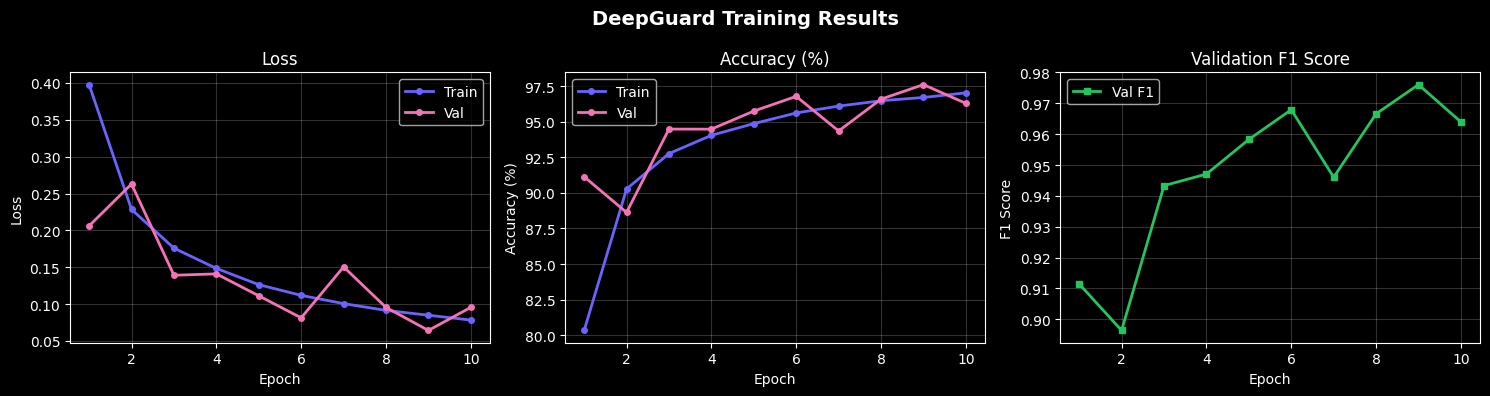

Plot saved to /content/training_curves.png


In [10]:
import matplotlib.pyplot as plt
import matplotlib.style as mplstyle

mplstyle.use('dark_background')

epochs_ran = len(history['train_loss'])
x          = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('DeepGuard Training Results', fontsize=14, fontweight='bold', color='white')

# ── Loss ──────────────────────────────────────────────────────────
axes[0].plot(x, history['train_loss'], label='Train', color='#6c63ff', linewidth=2, marker='o', markersize=4)
axes[0].plot(x, history['val_loss'],   label='Val',   color='#f472b6', linewidth=2, marker='o', markersize=4)
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.2)

# ── Accuracy ──────────────────────────────────────────────────────
axes[1].plot(x, [a*100 for a in history['train_acc']], label='Train', color='#6c63ff', linewidth=2, marker='o', markersize=4)
axes[1].plot(x, [a*100 for a in history['val_acc']],   label='Val',   color='#f472b6', linewidth=2, marker='o', markersize=4)
axes[1].set_title('Accuracy (%)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(alpha=0.2)

# ── F1 Score ──────────────────────────────────────────────────────
axes[2].plot(x, history['val_f1'], label='Val F1', color='#22c55e', linewidth=2, marker='s', markersize=4)
axes[2].set_title('Validation F1 Score')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('F1 Score')
axes[2].legend()
axes[2].grid(alpha=0.2)

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to /content/training_curves.png')

## 💾 Section 9: Save Trained Model + Metadata

In [11]:
import json

model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
model.eval()
print('Best model weights loaded.')

FINAL_WEIGHTS = f'{OUTPUT_DIR}/deepfake_model.pth'
torch.save(model.state_dict(), FINAL_WEIGHTS)

epochs_ran = len(history['train_loss'])
config = {
    'model':       MODEL_NAME,
    'input_size':  INPUT_SIZE,
    'num_classes': 2,
    'training_info': {
        'epochs':        epochs_ran,
        'batch_size':    BATCH_SIZE,
        'learning_rate': LEARNING_RATE,
        'best_val_loss': round(best_val_loss, 4),
        'best_val_acc':  round(max(history['val_acc']), 4),
        'best_val_f1':   round(max(history['val_f1']), 4),
    }
}
CONFIG_PATH = f'{OUTPUT_DIR}/model_config.json'
with open(CONFIG_PATH, 'w') as f:
    json.dump(config, f, indent=2)

LABELS_PATH = f'{OUTPUT_DIR}/class_labels.json'
with open(LABELS_PATH, 'w') as f:
    json.dump({'0': 'Real', '1': 'Fake'}, f, indent=2)

print('Files saved to /kaggle/working/:')
print(f'  {FINAL_WEIGHTS}')
print(f'  {CONFIG_PATH}')
print(f'  {LABELS_PATH}')
print('\nTo download: go to the Output tab (right panel) and click Download')


Best model weights loaded.
Files saved to /kaggle/working/:
  /kaggle/working/deepfake_model.pth
  /kaggle/working/model_config.json
  /kaggle/working/class_labels.json

To download: go to the Output tab (right panel) and click Download


## 📥 Section 10: Download Model to Your Computer

In [13]:
# Download your trained model from Kaggle
# -----------------------------------------
# 1. Look at the Output tab on the right side panel
# 2. You'll see: deepfake_model.pth, model_config.json, class_labels.json
# 3. Click the download arrow next to each file
# 4. Or click 'Download All' at the top of the Output tab

import os
print('Files in /kaggle/working/:')
for fname in sorted(os.listdir('/kaggle/working')):
    fpath = f'/kaggle/working/{fname}'
    if os.path.isfile(fpath):
        size_mb = os.path.getsize(fpath) / (1024*1024)
        print(f'  {fname}  ({size_mb:.1f} MB)')


Files in /kaggle/working/:
  class_labels.json  (0.0 MB)
  deepfake_model.pth  (90.0 MB)
  model_config.json  (0.0 MB)


## 🔬 Section 11: Inference — Test on a Single Image

Testing on: /kaggle/working/dataset/real/811_f00310.jpg


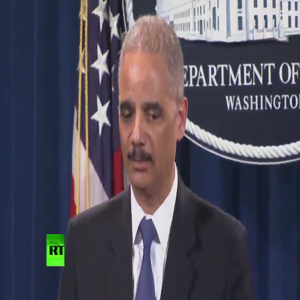

Face detected at [498, 130, 740, 464]

  Image       : 811_f00310.jpg
  Prediction  : Real
  Confidence  : 66.5%
  Real Prob   : 66.5%
  Fake Prob   : 33.5%
  Face Found  : True


In [14]:
from IPython.display import display
import os, random

# Pick a random real image from the dataset to test
real_images = [f for f in os.listdir(REAL_DIR) if f.lower().endswith(('.jpg','.jpeg','.png'))]
TEST_IMAGE_PATH = os.path.join(REAL_DIR, random.choice(real_images))
print(f'Testing on: {TEST_IMAGE_PATH}')

test_image = Image.open(TEST_IMAGE_PATH).convert('RGB')
display(test_image.resize((300, 300)))

mtcnn_infer   = MTCNN(image_size=224, margin=20, keep_all=False, device=DEVICE, post_process=False)
boxes, _      = mtcnn_infer.detect(test_image)
face_detected = False
input_img     = test_image

if boxes is not None and len(boxes) > 0:
    x1, y1, x2, y2 = [int(max(0, c)) for c in boxes[0]]
    input_img       = test_image.crop((x1, y1, x2, y2))
    face_detected   = True
    print(f'Face detected at [{x1}, {y1}, {x2}, {y2}]')
else:
    print('No face detected — using full image')

tensor = val_transform(input_img).unsqueeze(0).to(DEVICE)
model.eval()
with torch.no_grad():
    logits    = model(tensor)
    probs_out = torch.softmax(logits, dim=1)[0]

real_prob  = float(probs_out[0].item())
fake_prob  = float(probs_out[1].item())
predicted  = 'Fake' if fake_prob > real_prob else 'Real'
confidence = max(real_prob, fake_prob)

print('\n' + '='*40)
print(f'  Image       : {os.path.basename(TEST_IMAGE_PATH)}')
print(f'  Prediction  : {predicted}')
print(f'  Confidence  : {confidence*100:.1f}%')
print(f'  Real Prob   : {real_prob*100:.1f}%')
print(f'  Fake Prob   : {fake_prob*100:.1f}%')
print(f'  Face Found  : {face_detected}')
print('='*40)
